# Phase 3b — CDML Seed Identification: Can You Infer the Task from Confidences?

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

---

## What this notebook does

In Phase 3 we assumed the decoder always knows which seed was used for a given sample.
Here we relax that assumption:

> **Scenario:** An agent knows all 4 seeds (1000, 1001, 1002, 1003) but does NOT know
> which seed was applied to a specific test sample.
> It tries all 4 seeds in turn, observes the model's output confidence for each,
> and picks the seed that produces the highest confidence (max softmax probability).
> How often does it identify the correct seed?

This is a direct test of how much information leaks through the output distribution.
Under the correct seed the embedding is coherent → the classifier is confident.
Under a wrong seed the embedding is scrambled → the classifier should be unsure.

| Seed guess | Expected behaviour |
|---|---|
| Correct seed $s_k$ | $h \odot s_k$ is the sequence the classifier was trained on → **high confidence** |
| Wrong seed $s_j$ | $h \odot s_j$ is a scrambled vector → **low, near-uniform confidence** |

Random baseline: **25%** (1 out of 4 seeds chosen at random).

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using device: CUDA (NVIDIA GPU)')
else:
    DEVICE = torch.device('cpu')
    print('Using device: CPU')

Using device: MPS (Apple Silicon GPU)


## 1. Configuration — identical to Phase 3

In [2]:
TRAIN_DATA_DIR = '../Data/Dataset_1/train'
TEST_DATA_DIR  = '../Data/Dataset_1/test'

N_CHANNELS   = 6
WINDOW_SIZE  = 128
VAL_SPLIT    = 0.15
RANDOM_SEED  = 27

EPOCHS     = 50
BATCH_SIZE = 64
LR_INIT    = 1e-3
LR_DECAY   = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}
N_CLASSES_TOTAL = 118
EMBED_DIM       = 128

CDML_SEED_BASE = 1000
# The 4 seeds used in Phase 3, one per task
ALL_SEEDS = [CDML_SEED_BASE + k for k in range(4)]   # [1000, 1001, 1002, 1003]
print(f'Seeds: {ALL_SEEDS}')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Seeds: [1000, 1001, 1002, 1003]
Configuration set.


## 2. Data loading — identical to Phase 3

In [3]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])
print(f'Labels remapped: 0–{y_train_idx.max()}')


def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t  = torch.tensor(X_tr[mask_tr])
        y_t  = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())

Train: (33104, 6, 128)   Test: (3740, 6, 128)
Labels remapped: 0–117
Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test


## 3. Model definitions — identical to Phase 3

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 128),
            nn.Flatten(),
        )
        dummy     = torch.zeros(1, n_channels, WINDOW_SIZE)
        flat_size = self.feature_extractor(dummy).shape[1]
        self.embedding  = nn.Linear(flat_size, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))


def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    raw = rng.random(embed_dim)
    seq = np.where(raw >= 0.5, 1.0, -1.0).astype(np.float32)
    return torch.tensor(seq)


class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        seq = generate_cdml_sequence(embed_dim, seed)
        self.register_buffer('sequence', seq)

    def forward(self, h):
        return h * self.sequence


class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}

    def forward(self, x):
        h = self.backbone.embed(x)
        m = self.cdml(h)
        return self.backbone.classifier(m)

    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        seq = generate_cdml_sequence(self.embed_dim, seed).to(
            next(self.parameters()).device)
        self.cdml.sequence = seq


print('Models defined.')

Models defined.


## 4. Training utilities — identical to Phase 3

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct    += (model(X_b).argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        total_loss += criterion(logits, y_b).item() * len(y_b)
        correct    += (logits.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


def run_cdml_training(model, task_data, task_names,
                      epochs, lr_init, lr_decay, batch_size, device,
                      verbose_every=10):
    """
    Sequential training for CDML — same logic as Phase 3.
    Returns the trained model and the accuracy matrix.
    """
    n_tasks    = len(task_names)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        seed = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed)
        print(f'\nTask {step_idx+1}: {task_name}  (seed={seed})')

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        train_loader = DataLoader(task_data[task_name]['train'],
                                  batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(task_data[task_name]['val'],
                                  batch_size=batch_size, shuffle=False)

        for epoch in range(1, epochs + 1):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                              criterion, device)
            vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                print(f'  Epoch {epoch:>3}/{epochs}  '
                      f'train {tr_acc:.3f}  val {vl_acc:.3f}')

        # Evaluate on all tasks seen so far
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            _, acc = evaluate(model, test_loader, criterion, device)
            acc_matrix[step_idx, eval_idx] = acc
        print(f'  Accuracies after Task {step_idx+1}: '
              f'{[f"{acc_matrix[step_idx, j]*100:.1f}%" for j in range(step_idx+1)]}')

    return model, acc_matrix


print('Training utilities defined.')

Training utilities defined.


## 5. Load Phase 3 checkpoint (or retrain if not found)

In [6]:
import os

CHECKPOINT_PATH = 'checkpoint_phase3.pt'

model_cdml = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                           seed=CDML_SEED_BASE).to(DEVICE)

if os.path.exists(CHECKPOINT_PATH):
    print(f'Loading checkpoint from {CHECKPOINT_PATH} ...')
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model_cdml.load_state_dict(ckpt['model_cdml'])
    # Restore seed registry so set_task_sequence works correctly later
    model_cdml.seeds = ckpt['cdml_seeds']
    print('Checkpoint loaded.')
    print(f'  Seeds in model: {model_cdml.seeds}')
else:
    print(f'Checkpoint not found — training from scratch ({EPOCHS} epochs).')
    print('Tip: run Phase 3 first and save checkpoint_phase3.pt to skip this.')
    model_cdml, acc_matrix_cdml = run_cdml_training(
        model_cdml, task_data, task_names,
        EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE
    )
    print('\nTraining complete.')

Checkpoint not found — training from scratch (50 epochs).
Tip: run Phase 3 first and save checkpoint_phase3.pt to skip this.

Task 1: Task 1  (seed=1000)
  Epoch   1/50  train 0.686  val 0.941
  Epoch  10/50  train 0.998  val 0.981
  Epoch  20/50  train 1.000  val 0.992
  Epoch  30/50  train 1.000  val 0.993
  Epoch  40/50  train 1.000  val 0.992
  Epoch  50/50  train 1.000  val 0.992
  Accuracies after Task 1: ['89.9%']

Task 2: Task 2  (seed=1001)
  Epoch   1/50  train 0.819  val 0.936
  Epoch  10/50  train 0.999  val 0.974
  Epoch  20/50  train 0.999  val 0.982
  Epoch  30/50  train 1.000  val 0.980
  Epoch  40/50  train 1.000  val 0.981
  Epoch  50/50  train 1.000  val 0.982
  Accuracies after Task 2: ['67.4%', '94.6%']

Task 3: Task 3  (seed=1002)
  Epoch   1/50  train 0.836  val 0.943
  Epoch  10/50  train 1.000  val 0.975
  Epoch  20/50  train 1.000  val 0.978
  Epoch  30/50  train 1.000  val 0.977
  Epoch  40/50  train 1.000  val 0.977
  Epoch  50/50  train 1.000  val 0.977
  A

## 6. Seed identification experiment

For each test sample from task $k$ (encoded with seed $k$), we:
1. Try all 4 seeds in turn by setting `model.set_task_sequence(...)`
2. Compute the **max softmax probability** (confidence) for each candidate seed
3. Pick the seed with the highest confidence as the predicted seed
4. Check whether that matches the true seed

No knowledge of the true label is needed — only the output distribution.

In [7]:
@torch.no_grad()
def seed_identification_experiment(model, task_data, task_names, all_seeds, device,
                                    batch_size=64):
    """
    For each test sample from task k (true seed = all_seeds[k]), compute the
    max-softmax confidence under each of the n_seeds candidate seeds.
    Predicted seed = argmax of those confidences.

    Returns a dict with per-task results:
        confidences          : (n_samples, n_seeds) float array
        predicted_seed_idx   : (n_samples,) int array — index into all_seeds
        correct              : (n_samples,) bool array
        accuracy             : float
        seed_rank            : (n_seeds,) int array — how often each rank was
                               assigned to the correct seed (0=best, 3=worst)
    """
    model.eval()
    n_seeds      = len(all_seeds)
    per_task     = {}

    for true_idx, task_name in enumerate(task_names):
        true_seed   = all_seeds[true_idx]
        test_loader = DataLoader(task_data[task_name]['test'],
                                 batch_size=batch_size, shuffle=False)

        all_conf   = []   # (n_samples, n_seeds)
        all_labels = []

        for X_b, y_b in test_loader:
            X_b = X_b.to(device)
            batch_conf = []

            for seed in all_seeds:
                model.set_task_sequence('_probe', seed)
                logits = model(X_b)                              # (B, n_classes)
                probs  = torch.softmax(logits, dim=1)            # (B, n_classes)
                max_p  = probs.max(dim=1).values.cpu().numpy()   # (B,)
                batch_conf.append(max_p)

            all_conf.append(np.stack(batch_conf, axis=1))        # (B, n_seeds)
            all_labels.append(y_b.numpy())

        conf    = np.concatenate(all_conf,   axis=0)  # (n_samples, n_seeds)
        labels  = np.concatenate(all_labels, axis=0)  # (n_samples,)

        pred_idx = conf.argmax(axis=1)                           # (n_samples,)
        correct  = (pred_idx == true_idx)                        # (n_samples,)
        acc      = correct.mean()

        # Rank of the correct seed for each sample (0 = highest confidence)
        ranks    = (conf > conf[:, true_idx:true_idx+1]).sum(axis=1)  # 0..n_seeds-1
        rank_counts = np.bincount(ranks, minlength=n_seeds)

        per_task[task_name] = {
            'true_seed'          : true_seed,
            'true_seed_idx'      : true_idx,
            'confidences'        : conf,          # (n_samples, n_seeds)
            'labels'             : labels,
            'predicted_seed_idx' : pred_idx,
            'correct'            : correct,
            'accuracy'           : acc,
            'rank_counts'        : rank_counts,   # how often correct seed was rank 0,1,2,3
        }

        print(f'  {task_name} (true seed={true_seed}): '
              f'identification accuracy = {acc*100:.1f}%  '
              f'| rank-0 = {rank_counts[0]/len(correct)*100:.1f}%  '
              f'(random baseline = {100/n_seeds:.1f}%)')

    return per_task


print('Running seed identification experiment ...')
results = seed_identification_experiment(
    model_cdml, task_data, task_names, ALL_SEEDS, DEVICE
)

Running seed identification experiment ...
  Task 1 (true seed=1000): identification accuracy = 18.3%  | rank-0 = 18.3%  (random baseline = 25.0%)
  Task 2 (true seed=1001): identification accuracy = 29.6%  | rank-0 = 29.6%  (random baseline = 25.0%)
  Task 3 (true seed=1002): identification accuracy = 40.6%  | rank-0 = 40.6%  (random baseline = 25.0%)
  Task 4 (true seed=1003): identification accuracy = 95.2%  | rank-0 = 95.2%  (random baseline = 25.0%)


## 7. Summary statistics

In [8]:
n_seeds   = len(ALL_SEEDS)
baseline  = 1.0 / n_seeds

print('=' * 52)
print('Seed identification accuracy (random baseline = 25%)')
print('=' * 52)
accs = []
for task_name, r in results.items():
    accs.append(r['accuracy'])
    print(f'  {task_name}: {r["accuracy"]*100:.1f}%')

overall = np.mean(accs)
print(f'  ─────────────────────────────────')
print(f'  Overall mean: {overall*100:.1f}%  (random = {baseline*100:.1f}%)')
print()

print('Rank distribution of the correct seed (% of samples):')
print('  Rank 0 = highest confidence (correct); Rank 3 = lowest (wrong)')
for task_name, r in results.items():
    n = len(r['correct'])
    dist = r['rank_counts'] / n * 100
    print(f'  {task_name}: ' +
          ' | '.join([f'rank {i}: {dist[i]:.1f}%' for i in range(n_seeds)]))

Seed identification accuracy (random baseline = 25%)
  Task 1: 18.3%
  Task 2: 29.6%
  Task 3: 40.6%
  Task 4: 95.2%
  ─────────────────────────────────
  Overall mean: 45.9%  (random = 25.0%)

Rank distribution of the correct seed (% of samples):
  Rank 0 = highest confidence (correct); Rank 3 = lowest (wrong)
  Task 1: rank 0: 18.3% | rank 1: 19.0% | rank 2: 26.1% | rank 3: 36.7%
  Task 2: rank 0: 29.6% | rank 1: 28.0% | rank 2: 25.2% | rank 3: 17.3%
  Task 3: rank 0: 40.6% | rank 1: 27.6% | rank 2: 19.1% | rank 3: 12.7%
  Task 4: rank 0: 95.2% | rank 1: 3.3% | rank 2: 0.9% | rank 3: 0.6%


## 8. Visualizations

### 8a. Accuracy bar chart

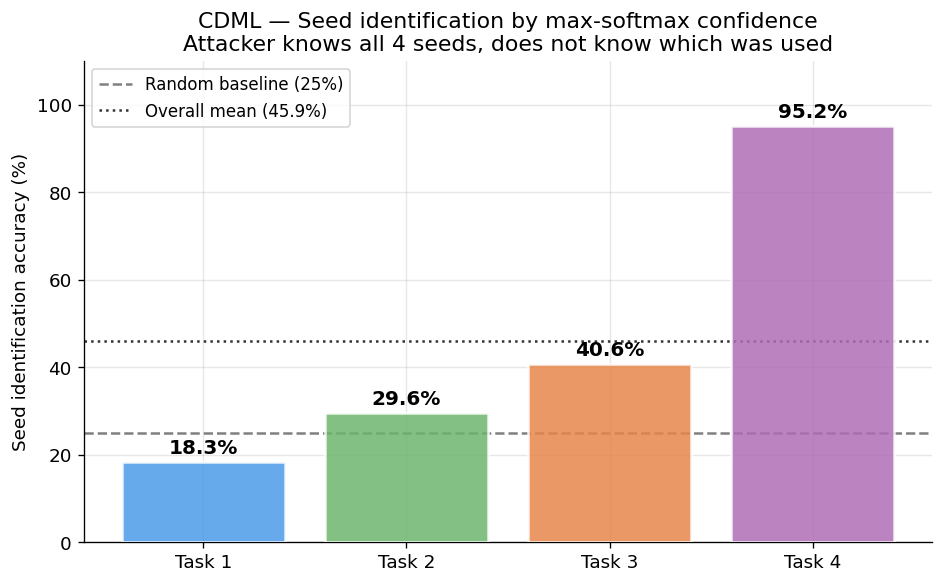

Saved: fig_seed_identification_accuracy.png


In [9]:
task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

fig, ax = plt.subplots(figsize=(8, 5))

task_labels_plot = list(results.keys())
acc_vals = [results[t]['accuracy'] * 100 for t in task_labels_plot]

bars = ax.bar(task_labels_plot, acc_vals, color=task_colors, alpha=0.85,
              edgecolor='white', linewidth=1.5, zorder=3)

# Random baseline
ax.axhline(baseline * 100, color='gray', linestyle='--', linewidth=1.5,
           label=f'Random baseline ({baseline*100:.0f}%)', zorder=2)

# Overall mean
ax.axhline(overall * 100, color='#333', linestyle=':', linewidth=1.5,
           label=f'Overall mean ({overall*100:.1f}%)', zorder=2)

# Value labels on bars
for bar, val in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Seed identification accuracy (%)')
ax.set_title('CDML — Seed identification by max-softmax confidence\n'
             'Attacker knows all 4 seeds, does not know which was used')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../Plots/fig_seed_identification_accuracy.png', bbox_inches='tight')
plt.show()
print('Saved: fig_seed_identification_accuracy.png')

### 8b. Confusion matrix (true seed × predicted seed)

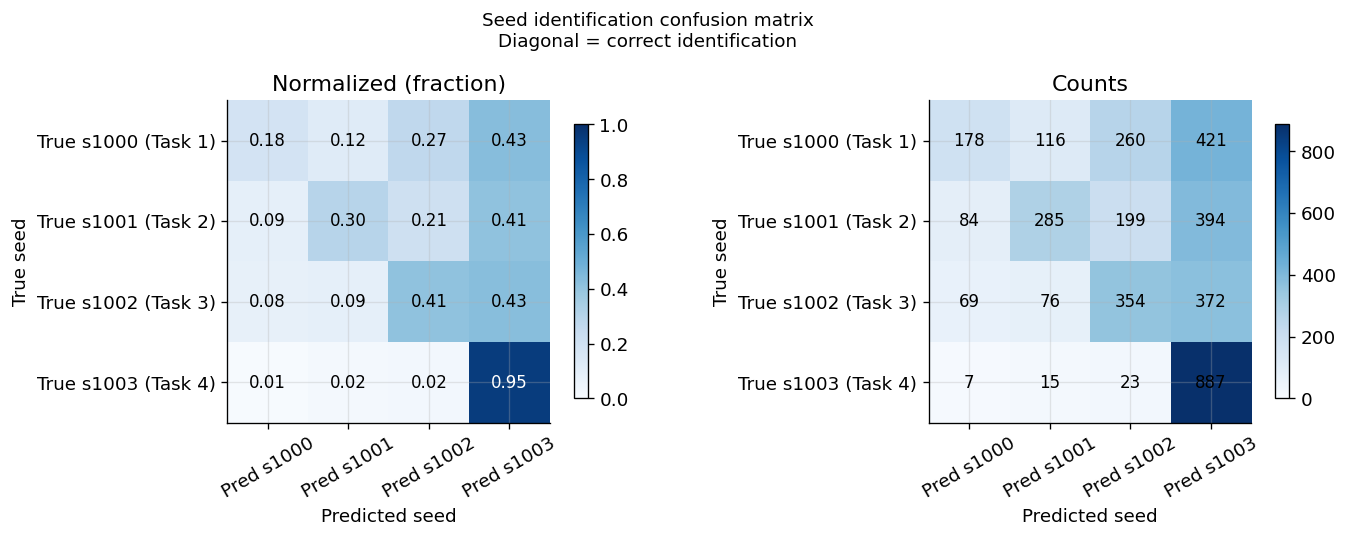

Saved: fig_seed_confusion_matrix.png


In [10]:
# Build confusion matrix: rows = true seed, cols = predicted seed
conf_matrix = np.zeros((n_seeds, n_seeds), dtype=int)
for task_idx, (task_name, r) in enumerate(results.items()):
    for pred in r['predicted_seed_idx']:
        conf_matrix[task_idx, pred] += 1

# Normalize by row (true seed count)
conf_matrix_norm = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, mat, title, fmt in [
    (axes[0], conf_matrix_norm, 'Normalized (fraction)', '.2f'),
    (axes[1], conf_matrix,      'Counts',                'd'),
]:
    im = ax.imshow(mat, cmap='Blues', vmin=0,
                   vmax=1 if fmt == '.2f' else conf_matrix.max())
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xticks(range(n_seeds))
    ax.set_yticks(range(n_seeds))
    ax.set_xticklabels([f'Pred s{CDML_SEED_BASE+i}' for i in range(n_seeds)], rotation=30)
    ax.set_yticklabels([f'True s{CDML_SEED_BASE+i} (Task {i+1})' for i in range(n_seeds)])
    ax.set_xlabel('Predicted seed')
    ax.set_ylabel('True seed')
    ax.set_title(title)
    for r in range(n_seeds):
        for c in range(n_seeds):
            v = mat[r, c]
            ax.text(c, r, format(v, fmt), ha='center', va='center',
                    fontsize=10,
                    color='white' if (fmt == '.2f' and v > 0.5) else 'black')

fig.suptitle('Seed identification confusion matrix\n'
             'Diagonal = correct identification', fontsize=11)
plt.tight_layout()
plt.savefig('../Plots/fig_seed_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: fig_seed_confusion_matrix.png')

### 8d. Rank distribution of the correct seed

For each sample, how often is the correct seed ranked 1st, 2nd, 3rd, 4th by confidence?
A perfect detector has 100% of samples at rank 0 (best).

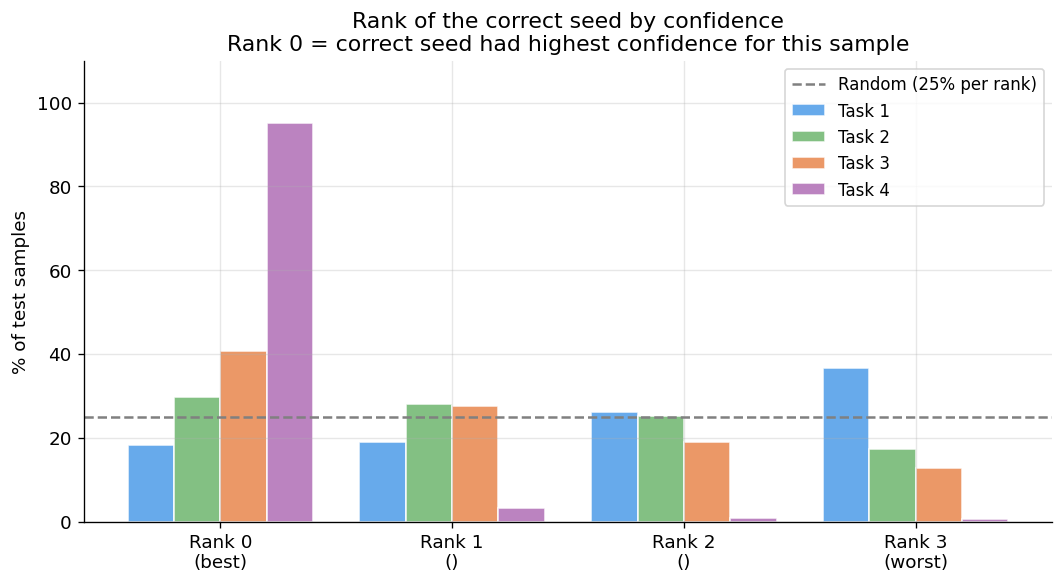

Saved: fig_seed_rank_distribution.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

x      = np.arange(n_seeds)
width  = 0.2
offset = np.linspace(-(n_seeds-1)/2, (n_seeds-1)/2, n_seeds) * width

for i, (task_name, r) in enumerate(results.items()):
    n     = len(r['correct'])
    fracs = r['rank_counts'] / n * 100
    ax.bar(x + offset[i], fracs, width=width, color=task_colors[i],
           alpha=0.85, label=task_name, edgecolor='white')

# Random baseline: each rank equally likely = 25%
ax.axhline(baseline * 100, color='gray', linestyle='--', linewidth=1.5,
           label=f'Random ({baseline*100:.0f}% per rank)')

ax.set_xticks(x)
ax.set_xticklabels([f'Rank {i}\n({"best" if i == 0 else "worst" if i == n_seeds-1 else ""})'  
                    for i in range(n_seeds)])
ax.set_ylabel('% of test samples')
ax.set_title('Rank of the correct seed by confidence\n'
             'Rank 0 = correct seed had highest confidence for this sample')
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('../Plots/fig_seed_rank_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig_seed_rank_distribution.png')

## 10. Oracle vs no-seed accuracy comparison

Re-run standard CDML evaluation (oracle: always use the correct seed) and compare
with the no-seed accuracy (classification accuracy when using the *identified* seed,
which may or may not be correct).

In [14]:
@torch.no_grad()
def evaluate_with_identified_seed(model, task_data, task_names,
                                   all_seeds, device, batch_size=64):
    """
    For each test sample:
      - Oracle mode  : use the correct seed → classification accuracy (upper bound)
      - No-seed mode : use the seed identified by max-softmax → degraded accuracy

    Returns per-task oracle and no-seed accuracies.
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()

    oracle_accs  = []
    noseed_accs  = []

    for true_idx, task_name in enumerate(task_names):
        true_seed   = all_seeds[true_idx]
        test_loader = DataLoader(task_data[task_name]['test'],
                                 batch_size=batch_size, shuffle=False)

        # ── Oracle accuracy ───────────────────────────────────────────────────
        model.set_task_sequence('_eval', true_seed)
        _, oracle_acc = evaluate(model, test_loader, criterion, device)
        oracle_accs.append(oracle_acc)

        # ── No-seed accuracy (use the seed ID result we already computed) ─────
        r          = results[task_name]   # from seed_identification_experiment
        conf_mat   = r['confidences']     # (n_samples, n_seeds)
        labels_all = r['labels']          # (n_samples,)

        # Rebuild predictions sample-by-sample using the identified seed
        # (group by identified seed and evaluate in one pass per seed)
        pred_indices = conf_mat.argmax(axis=1)   # (n_samples,)
        correct_cls  = 0
        total_cls    = 0

        # Build index map for efficient per-seed evaluation
        # Collect all (X, y) pairs and their identified seed
        all_X, all_y = [], []
        for X_b, y_b in test_loader:
            all_X.append(X_b)
            all_y.append(y_b)
        all_X = torch.cat(all_X, dim=0)
        all_y = torch.cat(all_y, dim=0)

        for seed_idx, seed in enumerate(all_seeds):
            mask = (pred_indices == seed_idx)
            if mask.sum() == 0:
                continue
            X_sub = all_X[mask].to(device)
            y_sub = all_y[mask].to(device)
            model.set_task_sequence('_eval', seed)
            logits = model(X_sub)
            correct_cls += (logits.argmax(1) == y_sub).sum().item()
            total_cls   += mask.sum().item()

        noseed_acc = correct_cls / total_cls if total_cls > 0 else 0.0
        noseed_accs.append(noseed_acc)

        print(f'  {task_name}: oracle={oracle_acc*100:.1f}%  '
              f'no-seed={noseed_acc*100:.1f}%  '
              f'(seed-ID acc={r["accuracy"]*100:.1f}%)')

    return oracle_accs, noseed_accs


print('Comparing oracle vs no-seed classification accuracy ...')
oracle_accs, noseed_accs = evaluate_with_identified_seed(
    model_cdml, task_data, task_names, ALL_SEEDS, DEVICE
)

Comparing oracle vs no-seed classification accuracy ...
  Task 1: oracle=43.1%  no-seed=13.5%  (seed-ID acc=18.3%)
  Task 2: oracle=60.2%  no-seed=22.3%  (seed-ID acc=29.6%)
  Task 3: oracle=63.4%  no-seed=32.8%  (seed-ID acc=40.6%)
  Task 4: oracle=97.6%  no-seed=94.0%  (seed-ID acc=95.2%)


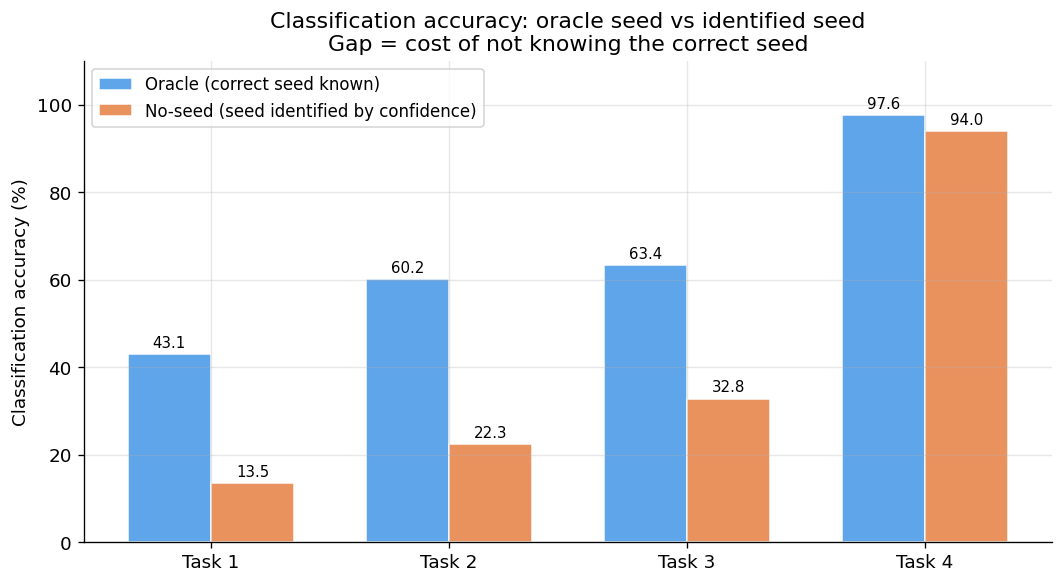

Saved: fig_oracle_vs_noseed_accuracy.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(n_seeds)
width = 0.35

oracle_vals  = [v * 100 for v in oracle_accs]
noseed_vals  = [v * 100 for v in noseed_accs]

b1 = ax.bar(x - width/2, oracle_vals, width, color='#4C9BE8', alpha=0.9,
            label='Oracle (correct seed known)', edgecolor='white')
b2 = ax.bar(x + width/2, noseed_vals, width, color='#E8864C', alpha=0.9,
            label='No-seed (seed identified by confidence)', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(task_names)
ax.set_ylabel('Classification accuracy (%)')
ax.set_ylim(0, 110)
ax.set_title('Classification accuracy: oracle seed vs identified seed\n'
             'Gap = cost of not knowing the correct seed')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../Plots/fig_oracle_vs_noseed_accuracy.png', bbox_inches='tight')
plt.show()
print('Saved: fig_oracle_vs_noseed_accuracy.png')